In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
import yfinance as yf

In [2]:
stock = 'RELIANCE.NS'

In [3]:
data = yf.download(stock, period='10y', interval='1d')

[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

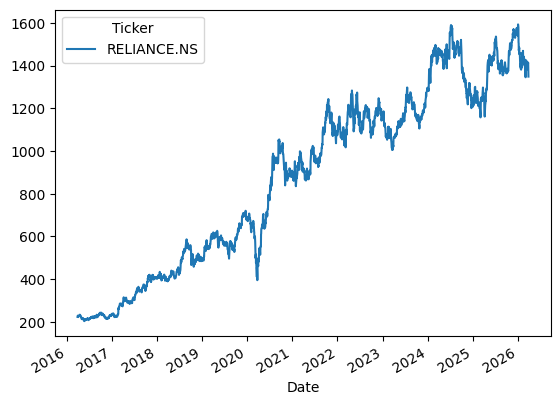

In [4]:
data = data['Close']
data.plot()

In [5]:
def adf(x):
  res = adfuller(x)
  print("Test-Statistic:", res[0])
  print("P-Value:", res[1])
  if res[1] < 0.05:
    print("Stationary")
  else:
    print("Non-Stationary")

In [6]:
adf(data)

Test-Statistic: -1.209398686124466
P-Value: 0.669539622808639
Non-Stationary


In [7]:
data['log_price'] = np.log(data)

In [8]:
adf(data['log_price'])

Test-Statistic: -1.7909603236814542
P-Value: 0.3849587876530825
Non-Stationary


<Axes: xlabel='Date'>

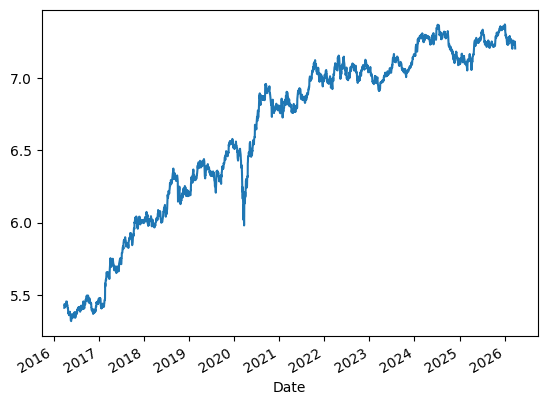

In [9]:
data['log_price'].plot()

In [10]:
data['log_ret'] = data['log_price'].diff()

<Axes: xlabel='Date'>

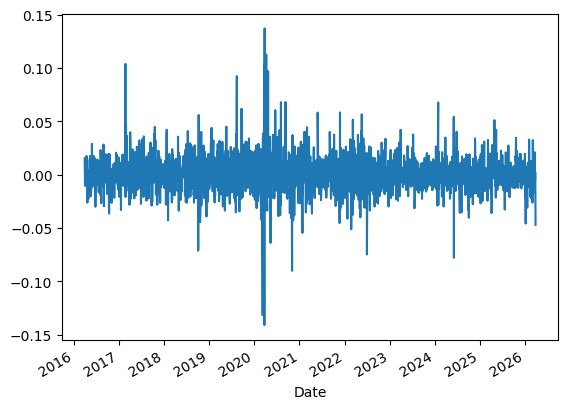

In [11]:
data['log_ret'].plot()

In [13]:
adf(data['log_ret'].dropna())

Test-Statistic: -14.975709914569318
P-Value: 1.1821368750027973e-27
Stationary


In [15]:
adfuller(data['log_ret'].dropna())

(np.float64(-14.975709914569318),
 np.float64(1.1821368750027973e-27),
 10,
 2460,
 {'1%': np.float64(-3.4330110311801567),
  '5%': np.float64(-2.862715621038473),
  '10%': np.float64(-2.5673958300284223)},
 np.float64(-12989.670340547656))

In [19]:
kpss(data['RELIANCE.NS'])

/var/folders/tw/2rqbm49j0kj2wfkk_jh33n440000gn/T/ipykernel_98679/2378735256.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss(data['RELIANCE.NS'])


(np.float64(7.817100257731928),
 np.float64(0.01),
 30,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [21]:
def kpss_helper(df):
    res = kpss(df)
    print('KPSS Test Statistic: ', res[0])
    print('KPSS p-value: ', res[1])
    if res[1] < 0.05:
        print("Non-Stationary")
    else:
        print("Stationary")

In [23]:
kpss_helper(data['RELIANCE.NS'])

KPSS Test Statistic:  7.817100257731928
KPSS p-value:  0.01
Non-Stationary


/var/folders/tw/2rqbm49j0kj2wfkk_jh33n440000gn/T/ipykernel_98679/3486552710.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  res = kpss(df)


In [24]:
kpss_helper(data['log_price'])

KPSS Test Statistic:  7.387795046281578
KPSS p-value:  0.01
Non-Stationary


/var/folders/tw/2rqbm49j0kj2wfkk_jh33n440000gn/T/ipykernel_98679/3486552710.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  res = kpss(df)


In [26]:
kpss_helper(data['log_ret'].dropna())

KPSS Test Statistic:  0.2012912152531023
KPSS p-value:  0.1
Stationary


/var/folders/tw/2rqbm49j0kj2wfkk_jh33n440000gn/T/ipykernel_98679/3486552710.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  res = kpss(df)
